# MMM Report: Faster Time-to-Insights for Marketing Stakeholders

This notebook is designed for marketing teams that need structured insights quickly, without digging through technical modeling details.

The goal is to fit a multidimensional MMM and generate a report-ready table bundle using `MMMReport.to_dataframe()`.

From a business perspective, this helps answer questions such as:

- How much each component (baseline, controls, media) contributes to outcomes.
- Which channels have the strongest contribution share and ROAS signals.
- Where we should focus immediate stakeholder discussions and budget decisions.

We keep the modeling section concise and focus on actionable outputs.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation, MMMReport
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.paths import data_dir
from pymc_marketing.prior import Prior
from pymc_marketing.special_priors import LaplacePrior, LogNormalPrior

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 8

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "mmm_report"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## 1) Load the multidimensional example dataset

We reuse the same dataset used in the multidimensional MMM example to keep this report workflow consistent with existing documentation.

In [3]:
data_path = data_dir / "mmm_multidimensional_example.csv"
data_df = pd.read_csv(data_path, parse_dates=["date"])

data_df.head()

,date,geo,x1,x2,event_1,event_2,y
0,2022-06-06,geo_a,5527.640078,0.000000,0,0,2647.596355
1,2022-06-06,geo_b,8849.257500,8063.918386,0,0,682.406280
2,2022-06-13,geo_a,6692.655692,0.000000,0,0,5020.823907
3,2022-06-13,geo_b,9073.817994,9354.014585,0,0,3753.104897
4,2022-06-20,geo_a,7124.016733,0.000000,0,0,6184.322132


## 2) Fit the MMM (same structure as the multidimensional example)

We keep the model structure aligned with the reference example while keeping the explanation lightweight: we are fitting a model that estimates channel impact over time and across geographies.

In [4]:
beta_prior = LogNormalPrior(
    mean=Prior("Gamma", mu=0.25, sigma=0.10, dims="channel"),
    std=Prior("Exponential", scale=0.10, dims="channel"),
    dims=("channel", "geo"),
    centered=False,
)

lam_prior = Prior("Gamma", mu=0.5, sigma=0.25, dims="channel")
saturation = LogisticSaturation(
    priors={
        "beta": beta_prior,
        "lam": lam_prior,
    },
)

alpha_prior = Prior("Beta", alpha=2, beta=5, dims=("geo", "channel"))
adstock = GeometricAdstock(
    priors={"alpha": alpha_prior},
    l_max=8,
)

model_config = {
    "intercept": Prior("Gamma", mu=0.5, sigma=0.25, dims="geo"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
    "gamma_fourier": LaplacePrior(
        mu=0,
        b=Prior("HalfNormal", sigma=0.2),
        dims=("geo", "fourier_mode"),
        centered=False,
    ),
    "likelihood": Prior(
        "TruncatedNormal",
        lower=0,
        sigma=Prior("HalfNormal", sigma=1.5),
        dims=("date", "geo"),
    ),
}

mmm = MMM(
    date_column="date",
    target_column="y",
    channel_columns=["x1", "x2"],
    control_columns=["event_1", "event_2"],
    dims=("geo",),
    scaling={
        "channel": {"method": "max", "dims": ()},
        "target": {"method": "max", "dims": ()},
    },
    adstock=adstock,
    saturation=saturation,
    yearly_seasonality=2,
    model_config=model_config,
)

x_train = data_df.drop(columns=["y"])
y_train = data_df["y"]

In [5]:
mmm.build_model(X=x_train, y=y_train)

mmm.add_original_scale_contribution_variable(
    var=["channel_contribution"],
)

mmm.fit(
    X=x_train,
    y=y_train,
    chains=4,
    target_accept=0.95,
    nuts_sampler="nutpie",
    random_seed=rng,
)

mmm.sample_posterior_predictive(
    X=x_train,
    random_seed=rng,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.17,15
,2000,2,0.21,31
,2000,0,0.21,31
,2000,0,0.21,63


Output()

Sampling: [y]


Output()

<xarray.Dataset> Size: 10MB
Dimensions:  (date: 159, geo: 2, sample: 4000)
Coordinates:
  * date     (date) datetime64[ns] 1kB 2022-06-06 2022-06-13 ... 2025-06-16
  * geo      (geo) <U5 40B 'geo_a' 'geo_b'
  * sample   (sample) object 32kB MultiIndex
  * chain    (sample) int64 32kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 32kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y        (date, geo, sample) float64 10MB 0.2492 0.2684 ... 0.4533 0.3077
Attributes:
    created_at:                 2026-03-23T14:00:45.496559+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1

## 3) Build the stakeholder-ready table package with `MMMReport`

`to_dataframe()` is the fastest handoff for analysis teams because it returns structured tables that can be quickly filtered, reviewed, and shared.

Sampling: []


Output()

/Users/juanitorduz/Documents/pymc-marketing/pymc_marketing/mmm/plot.py:3455: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/Users/juanitorduz/Documents/pymc-marketing/pymc_marketing/mmm/plot.py:3455: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


['arviz_summary',
 'channel_contributions',
 'diagnostics',
 'model_overview',
 'posterior_predictive',
 'roas_elementwise',
 'saturation_curves',
 'sensitivity_analysis',
 'total_contributions']

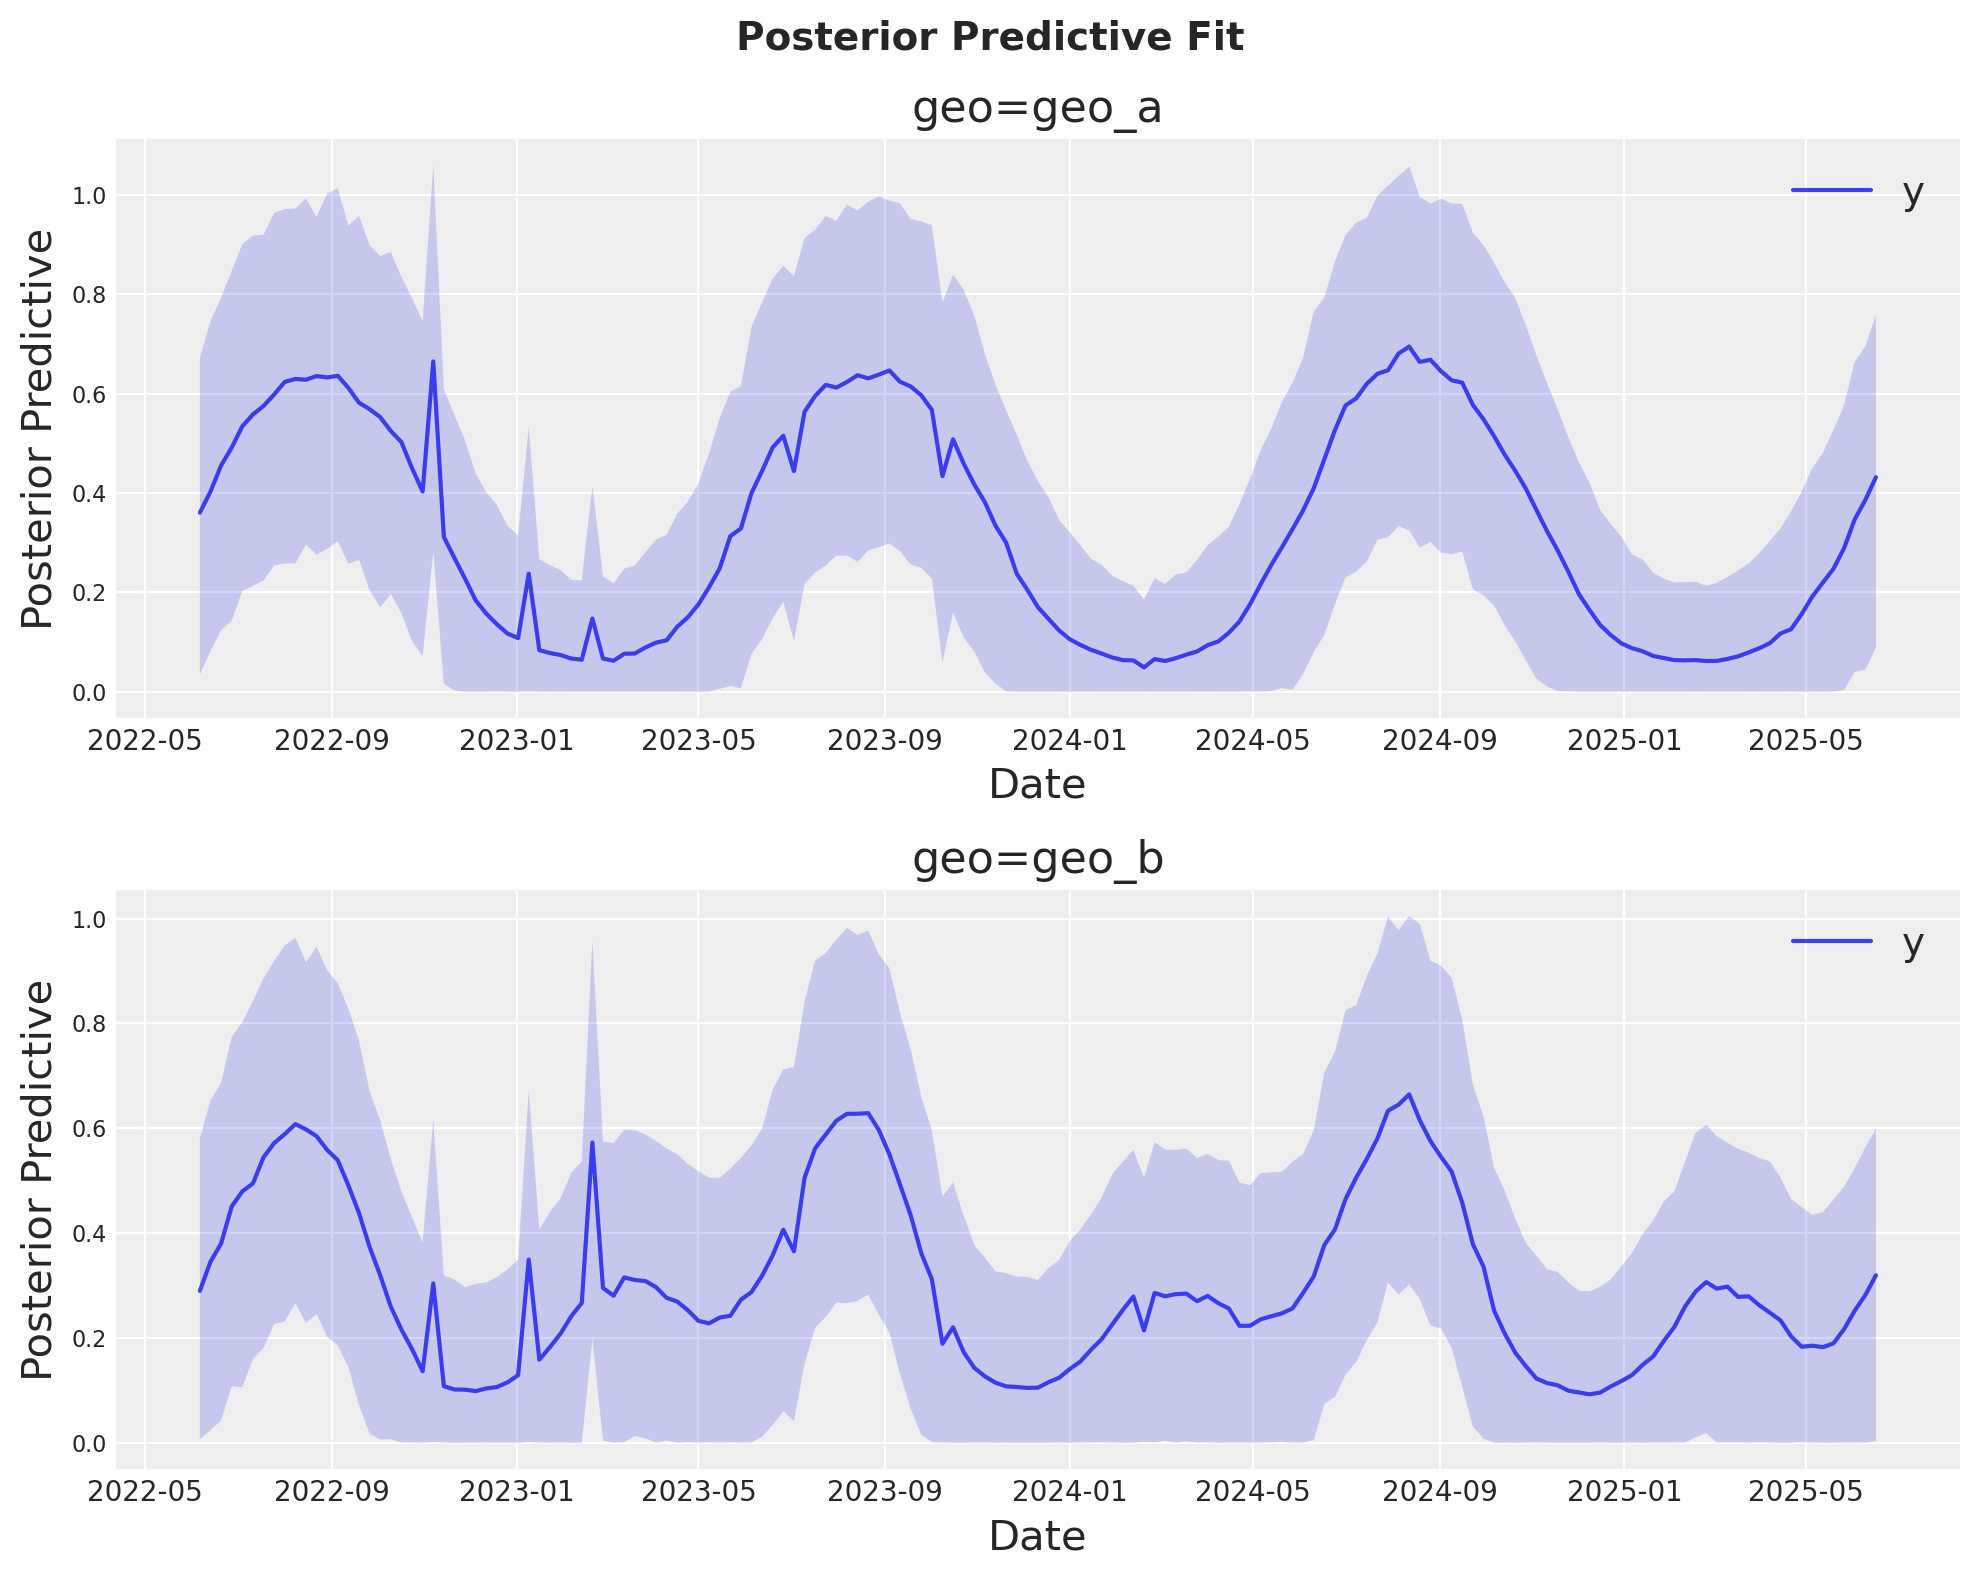

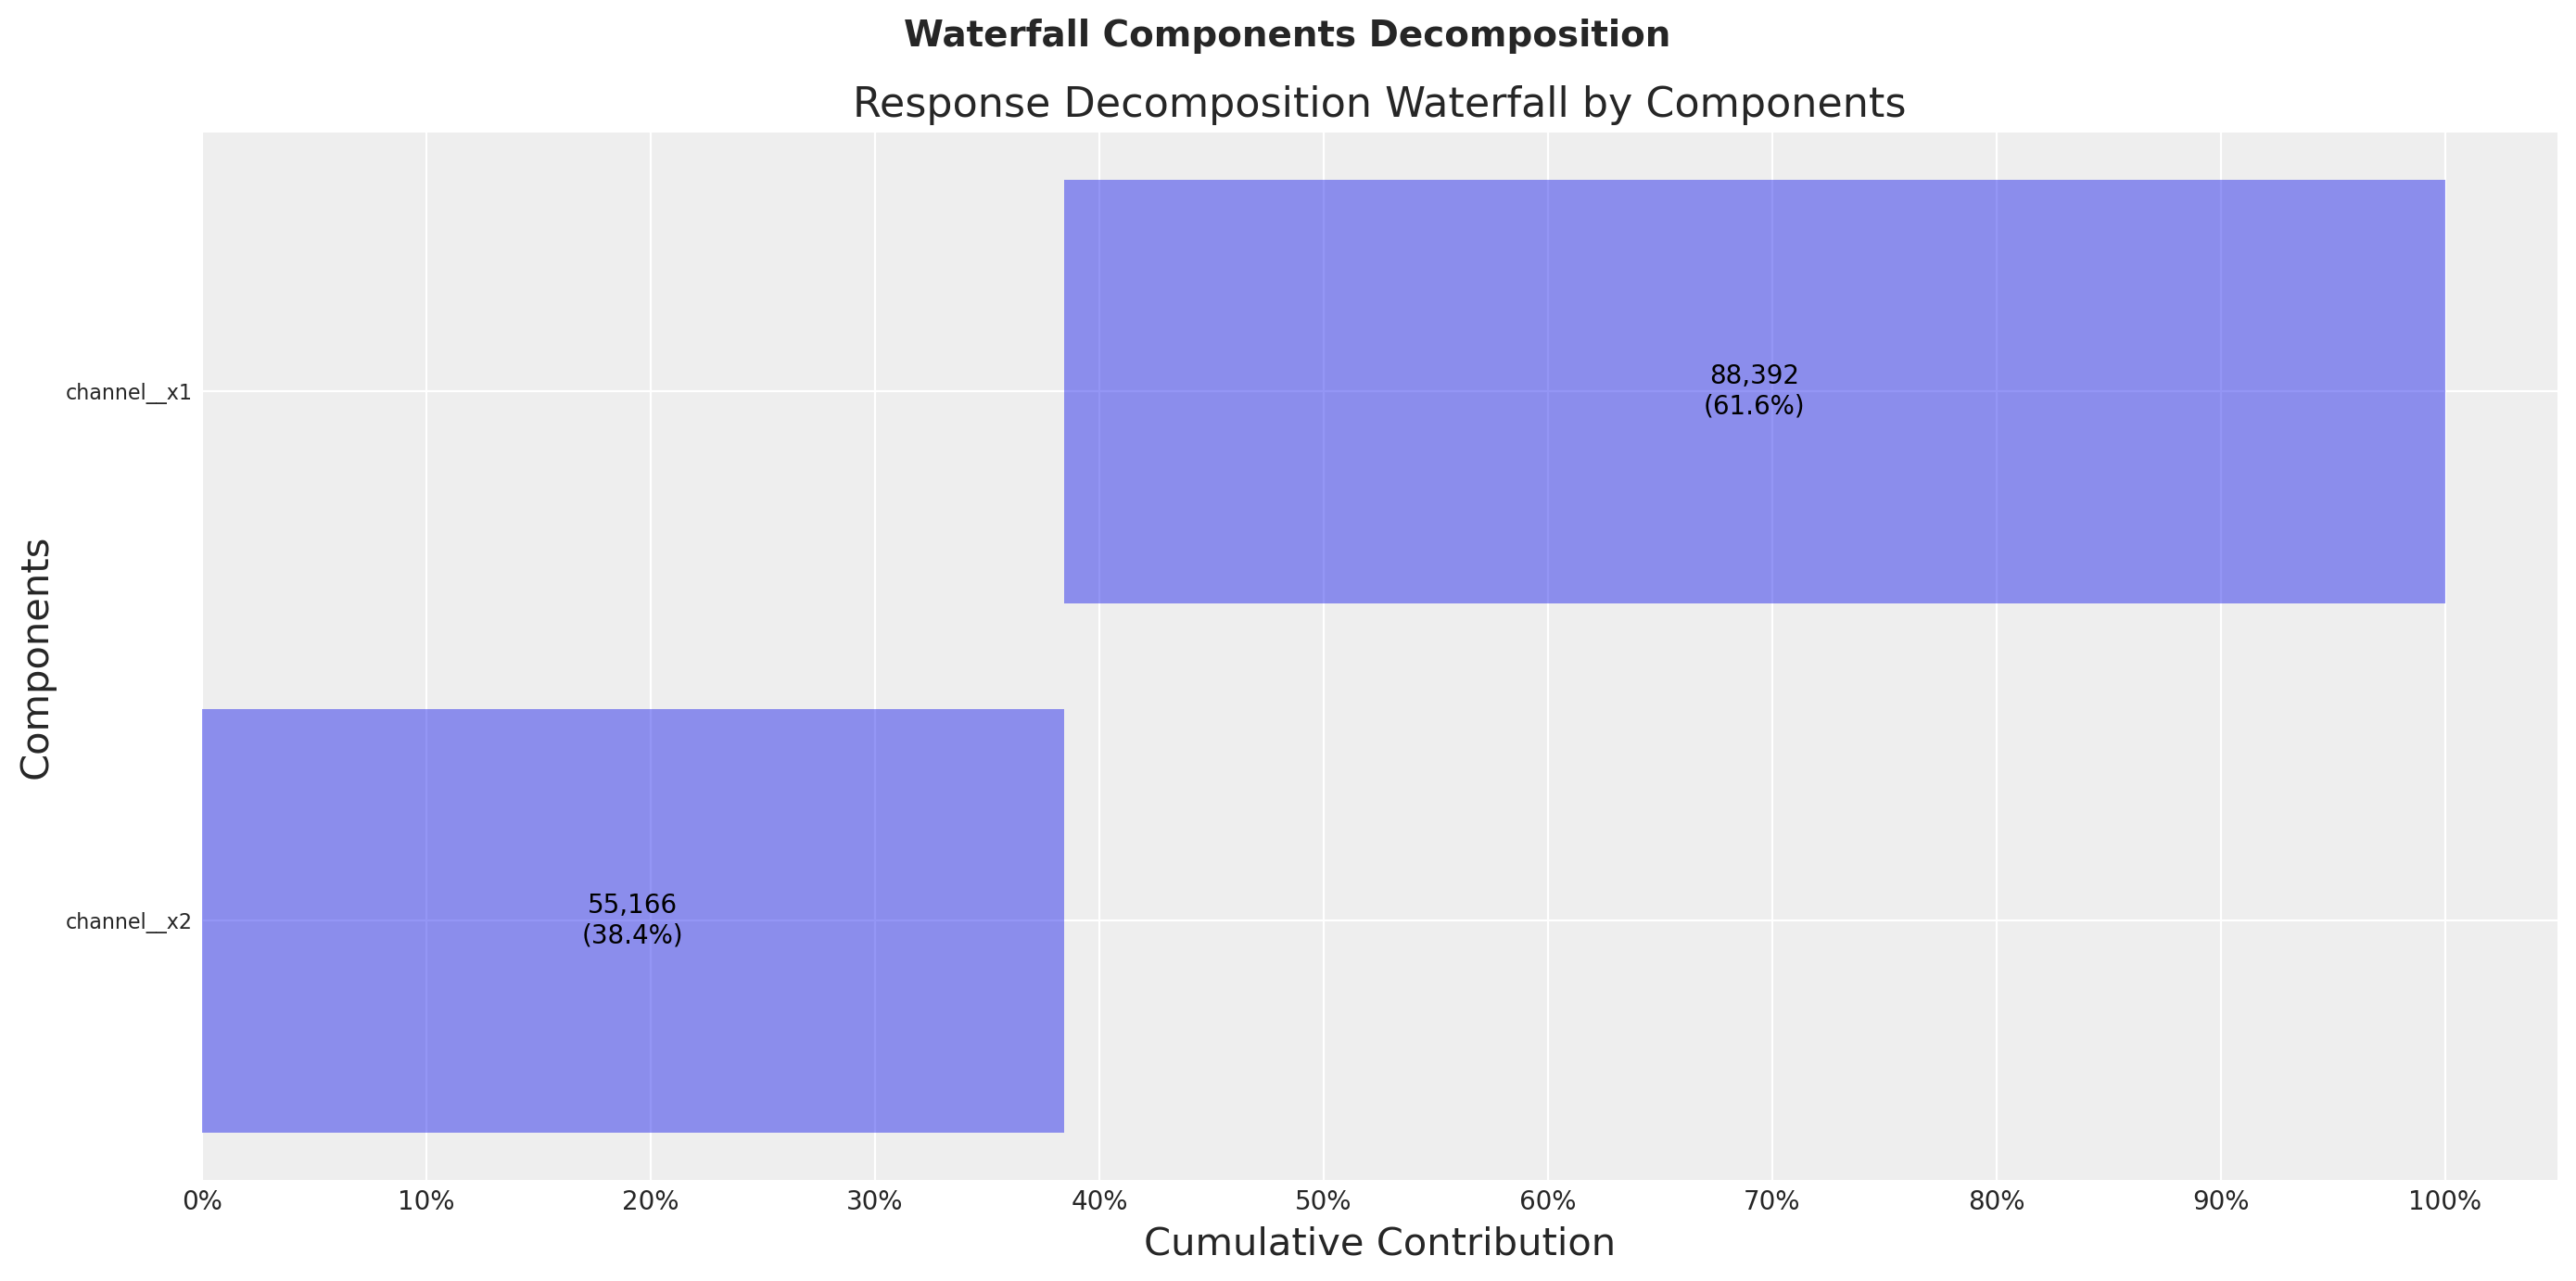

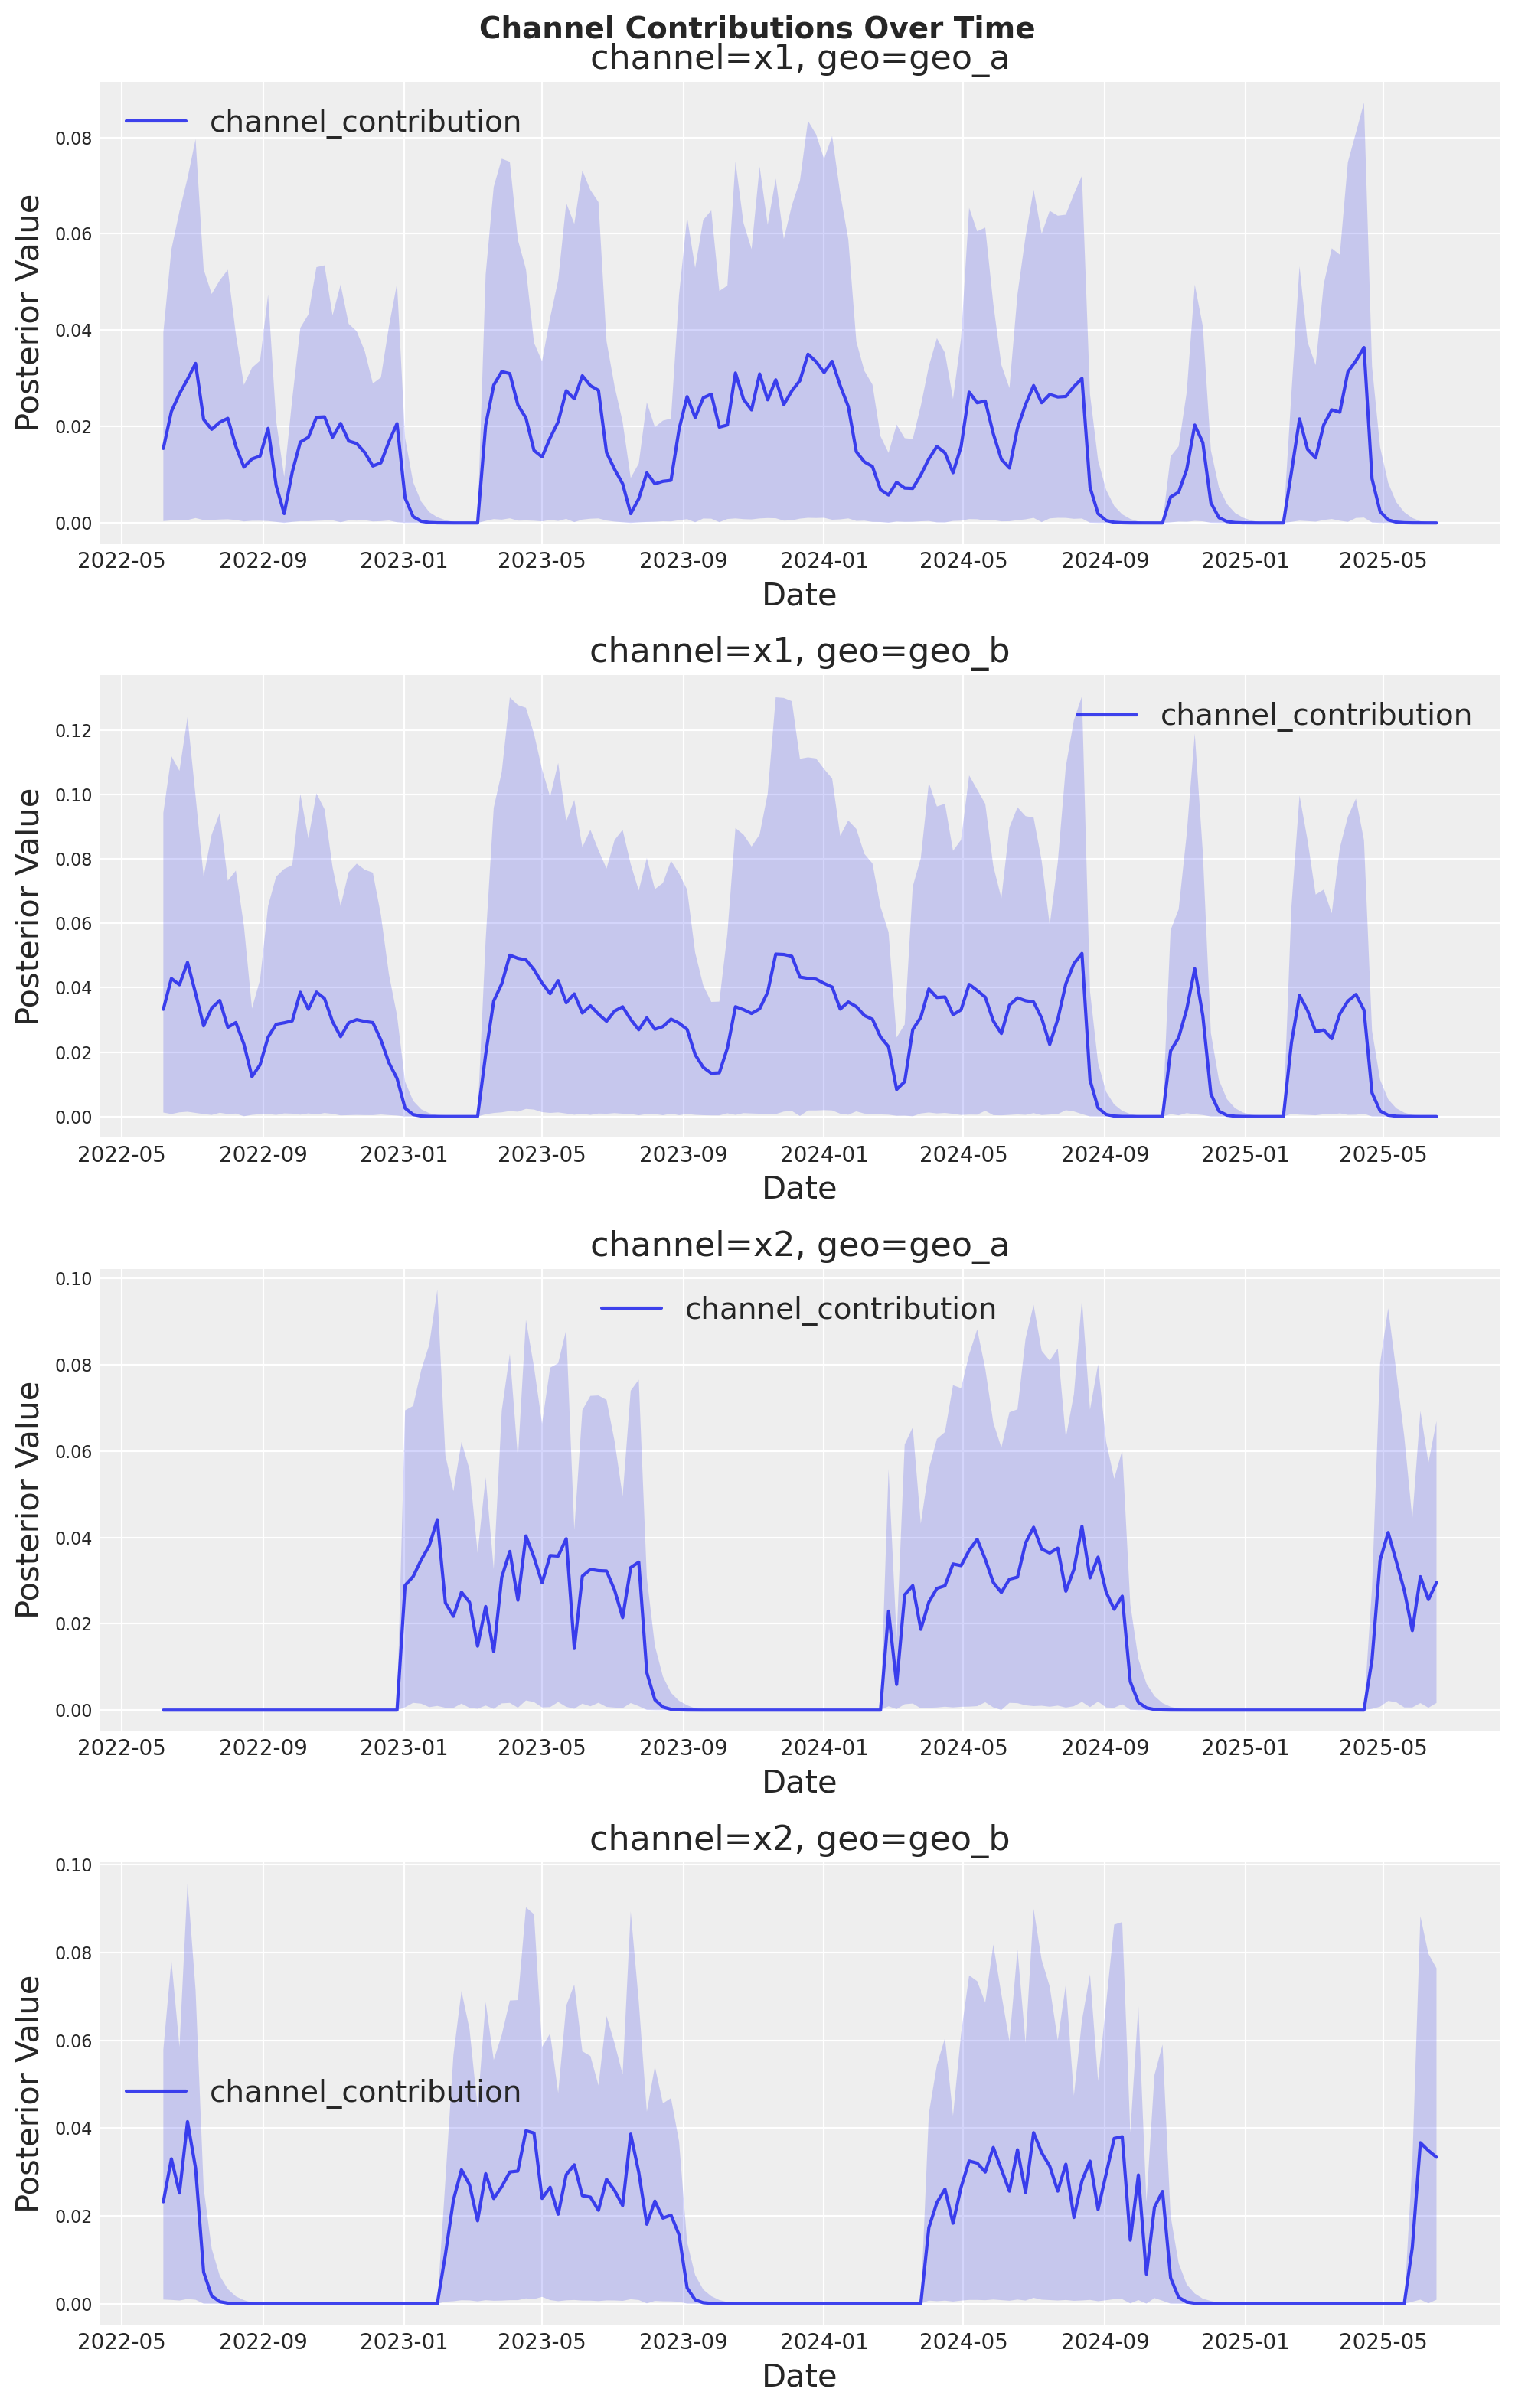

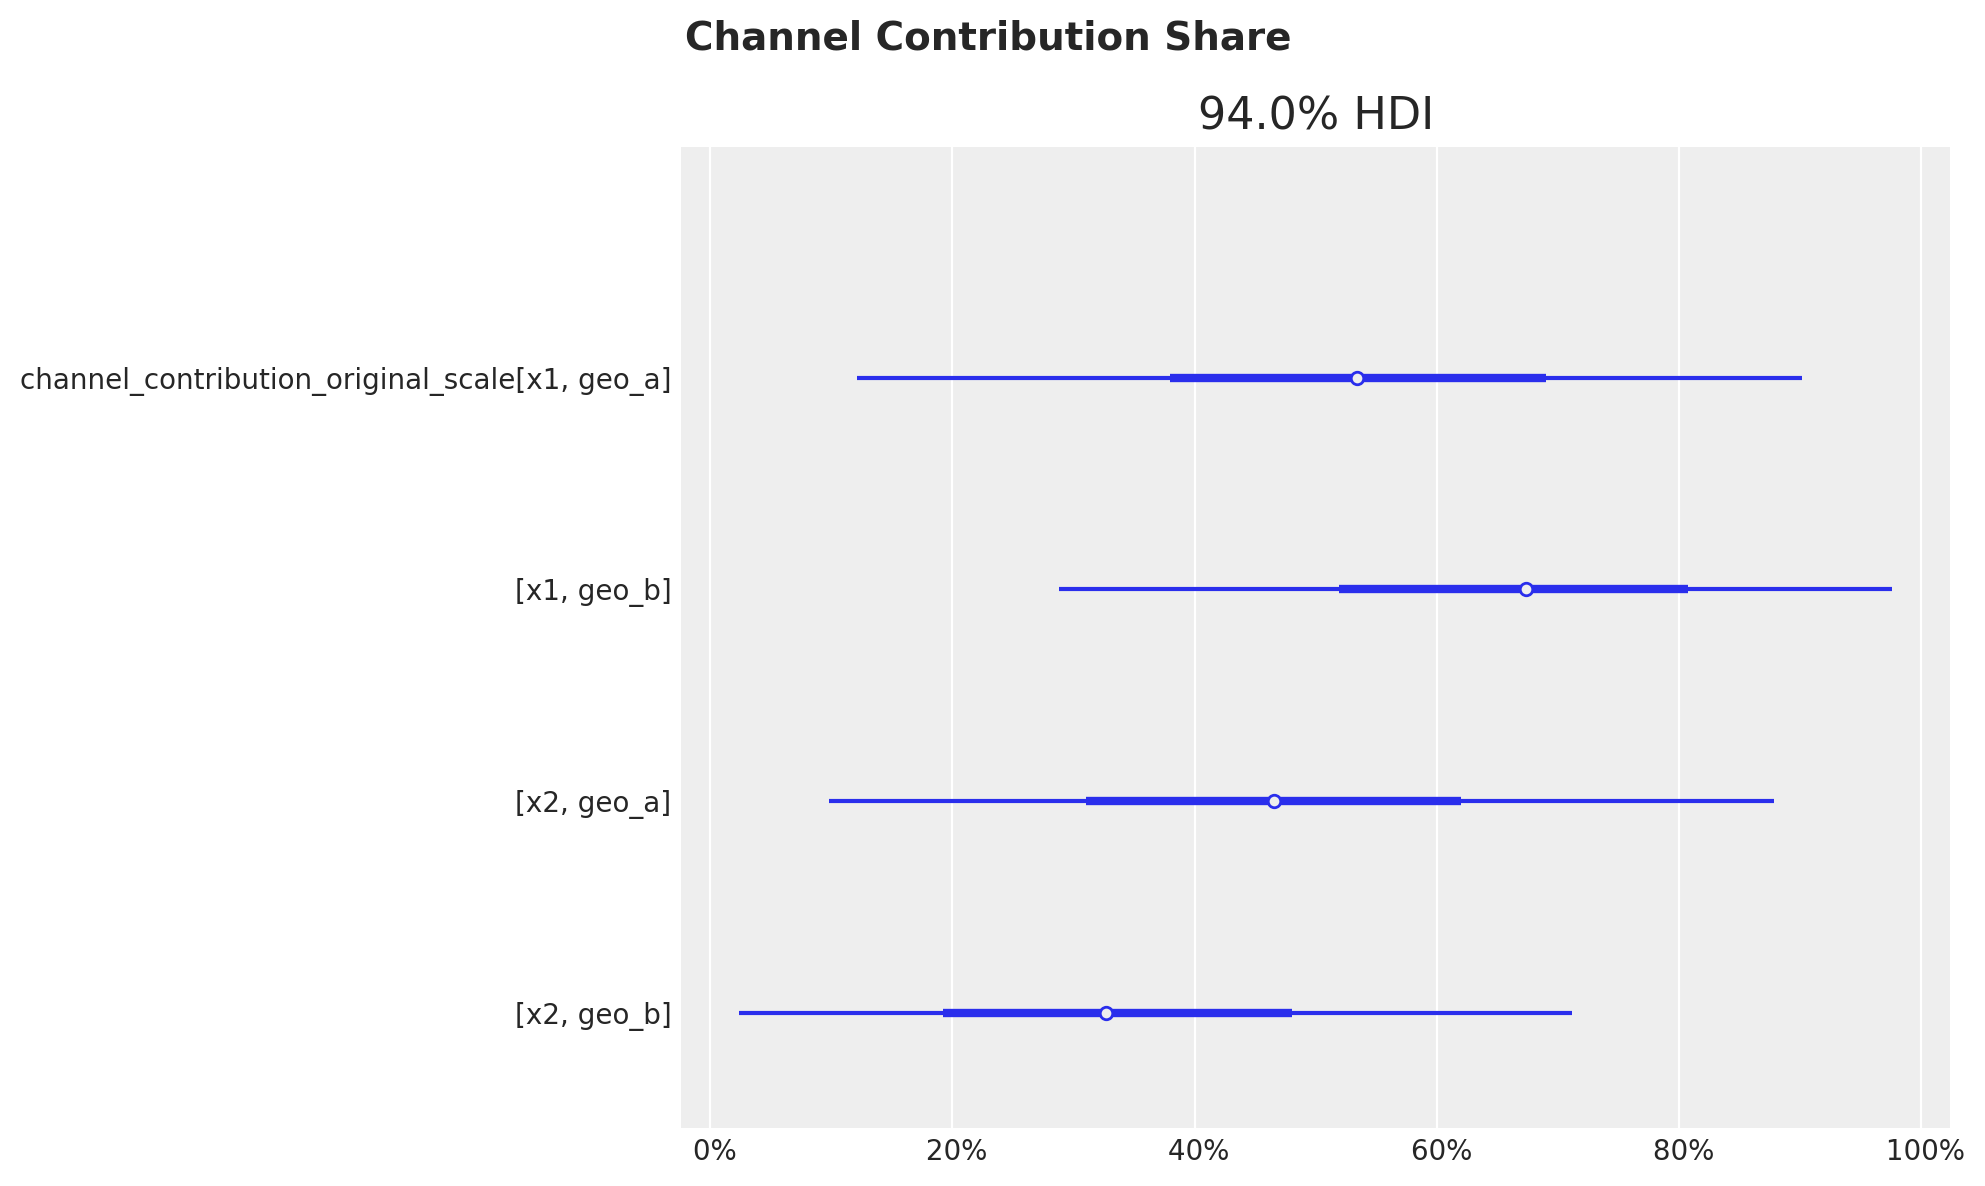

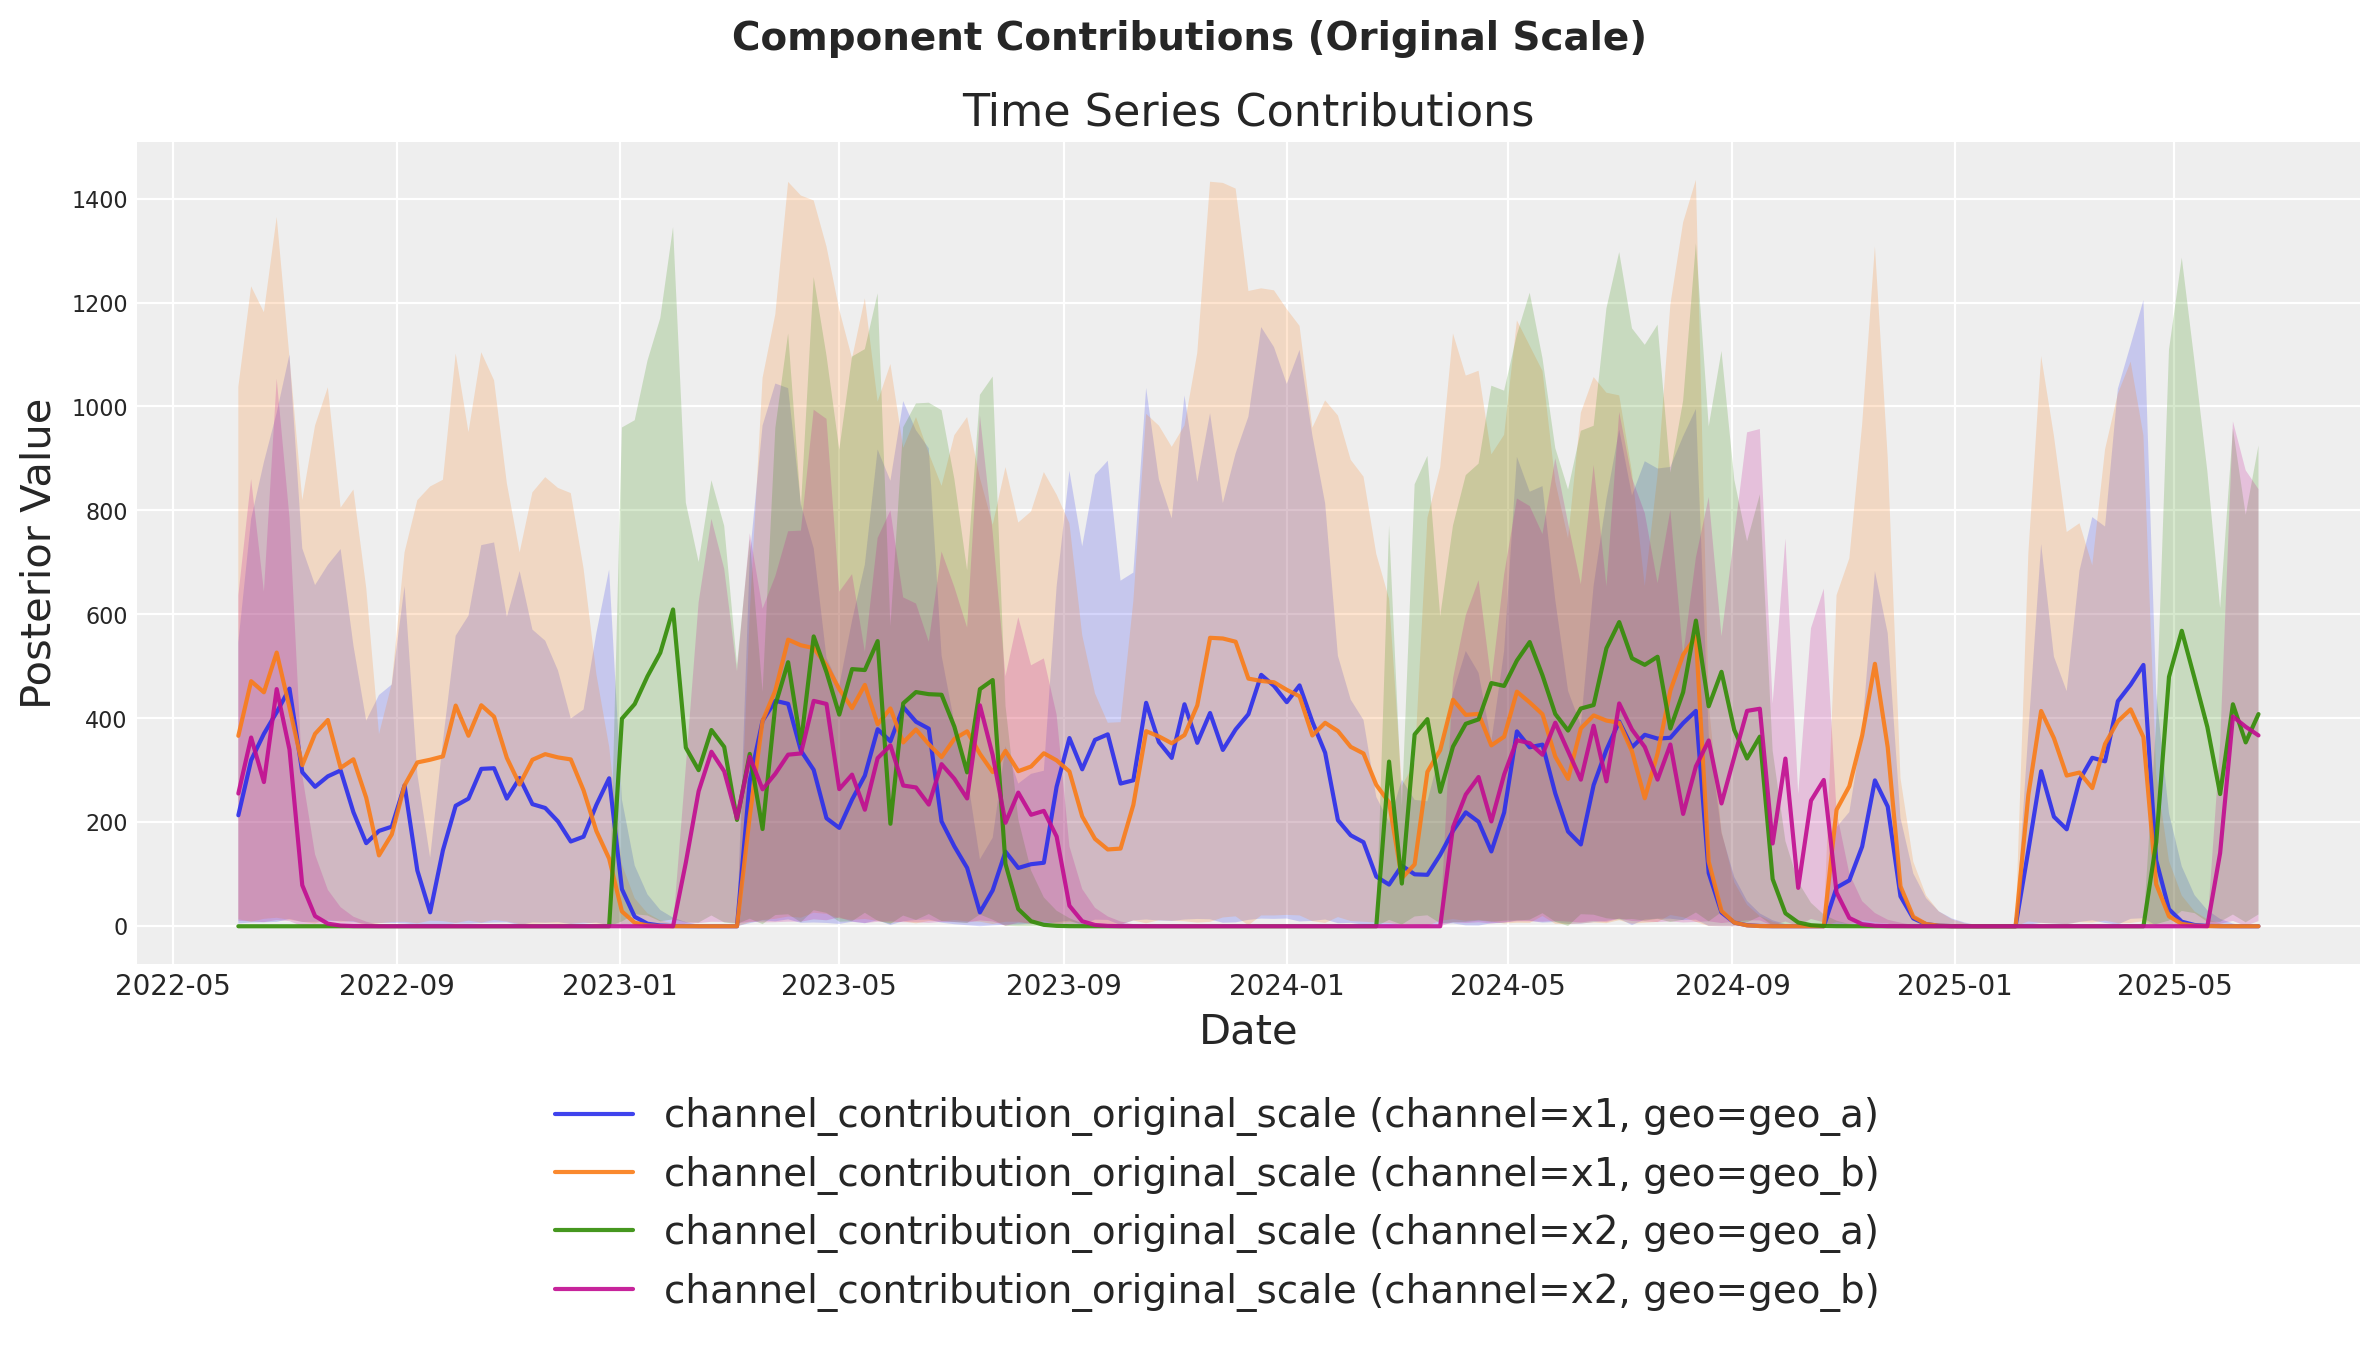

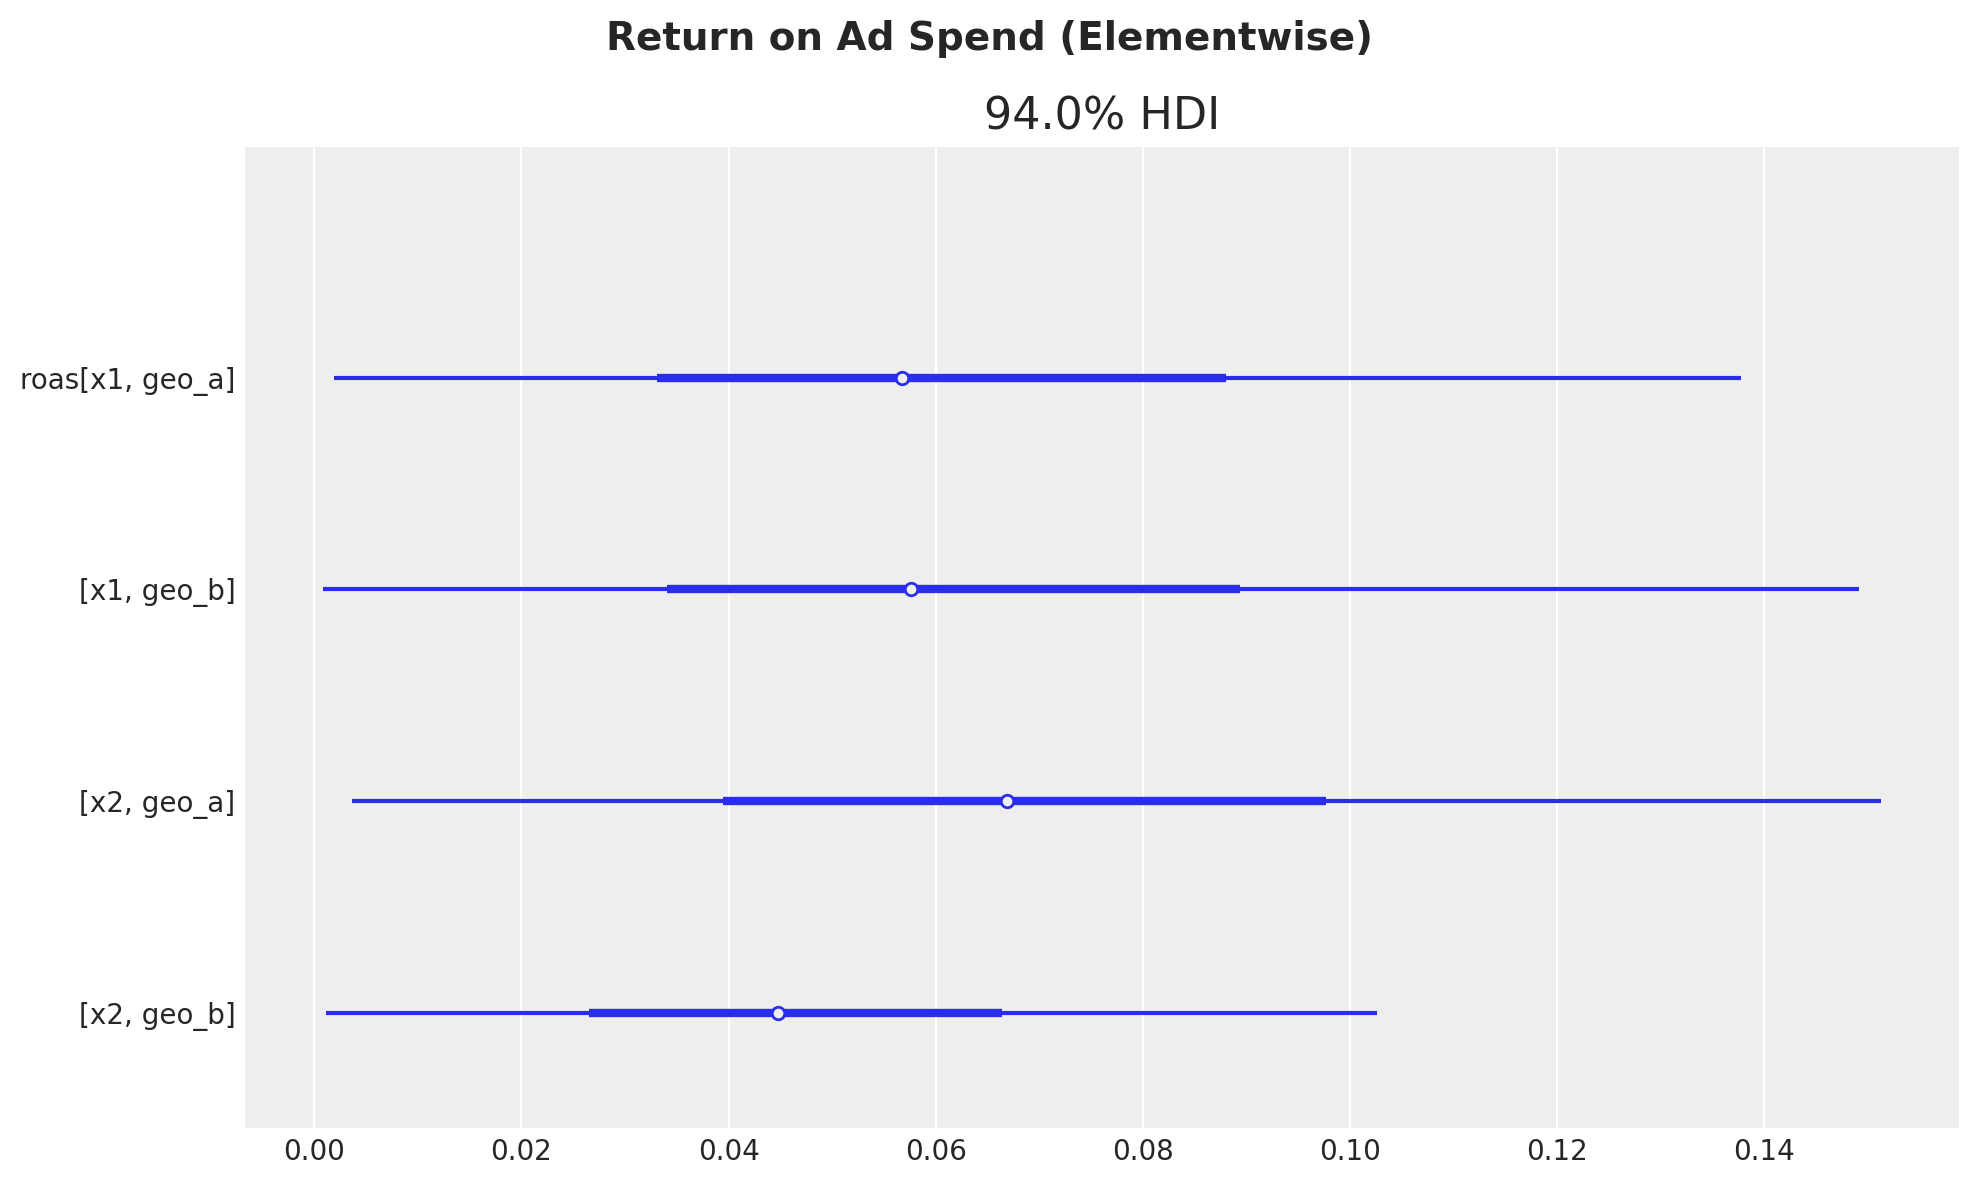

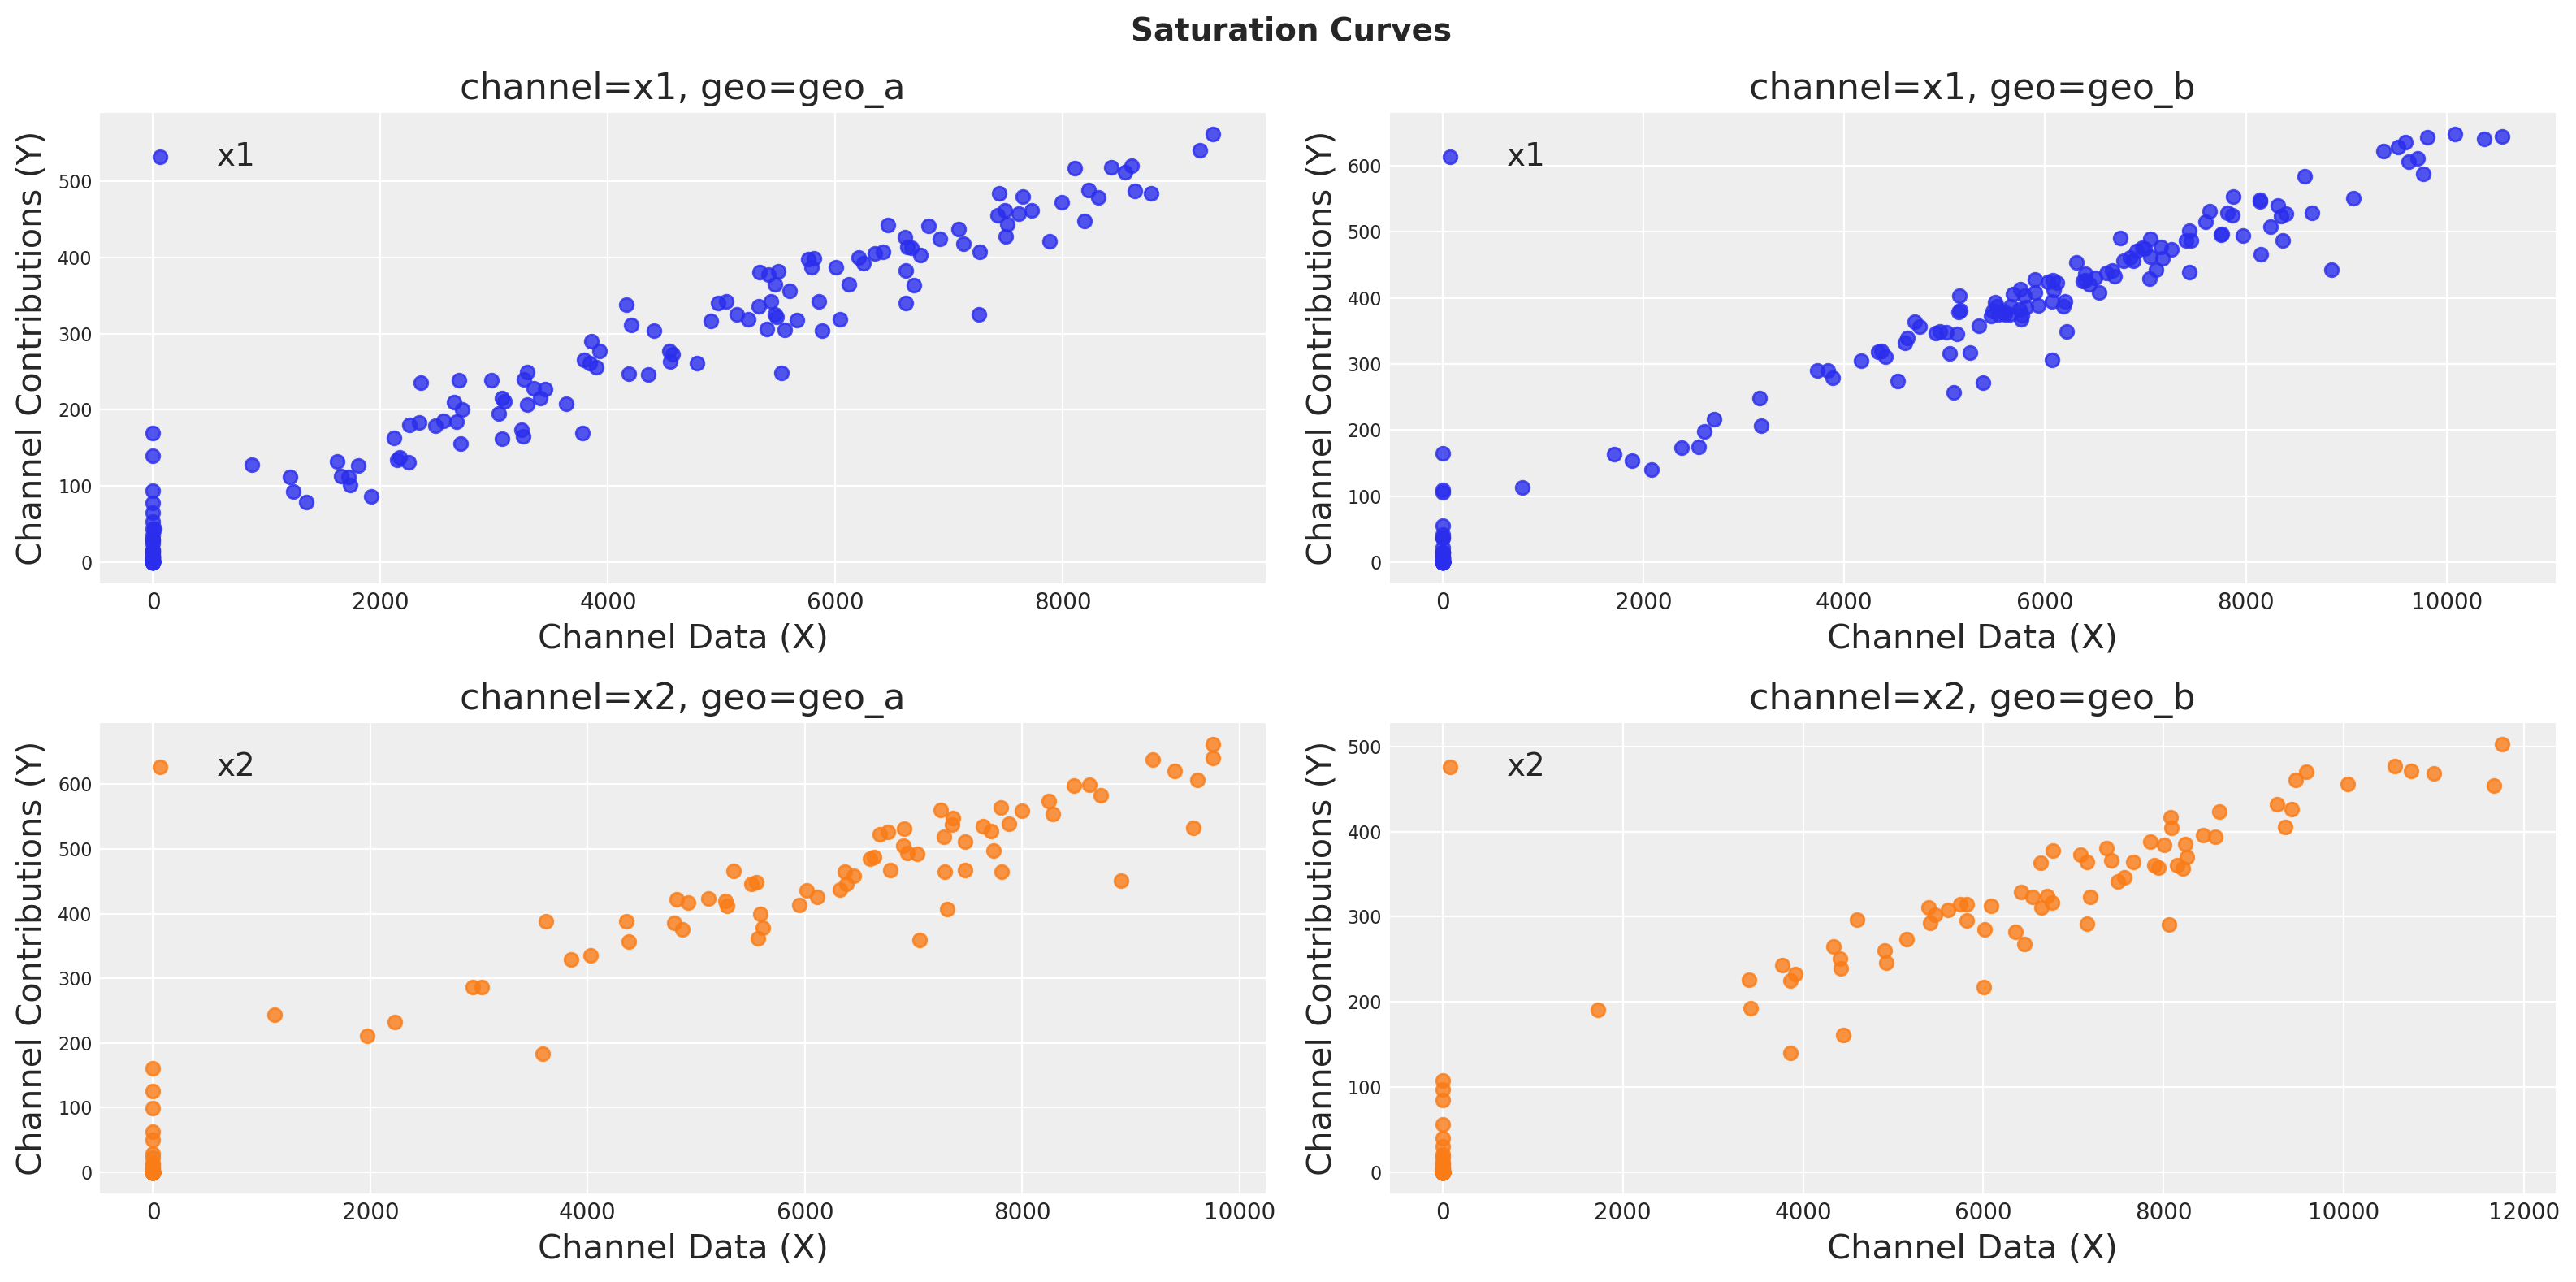

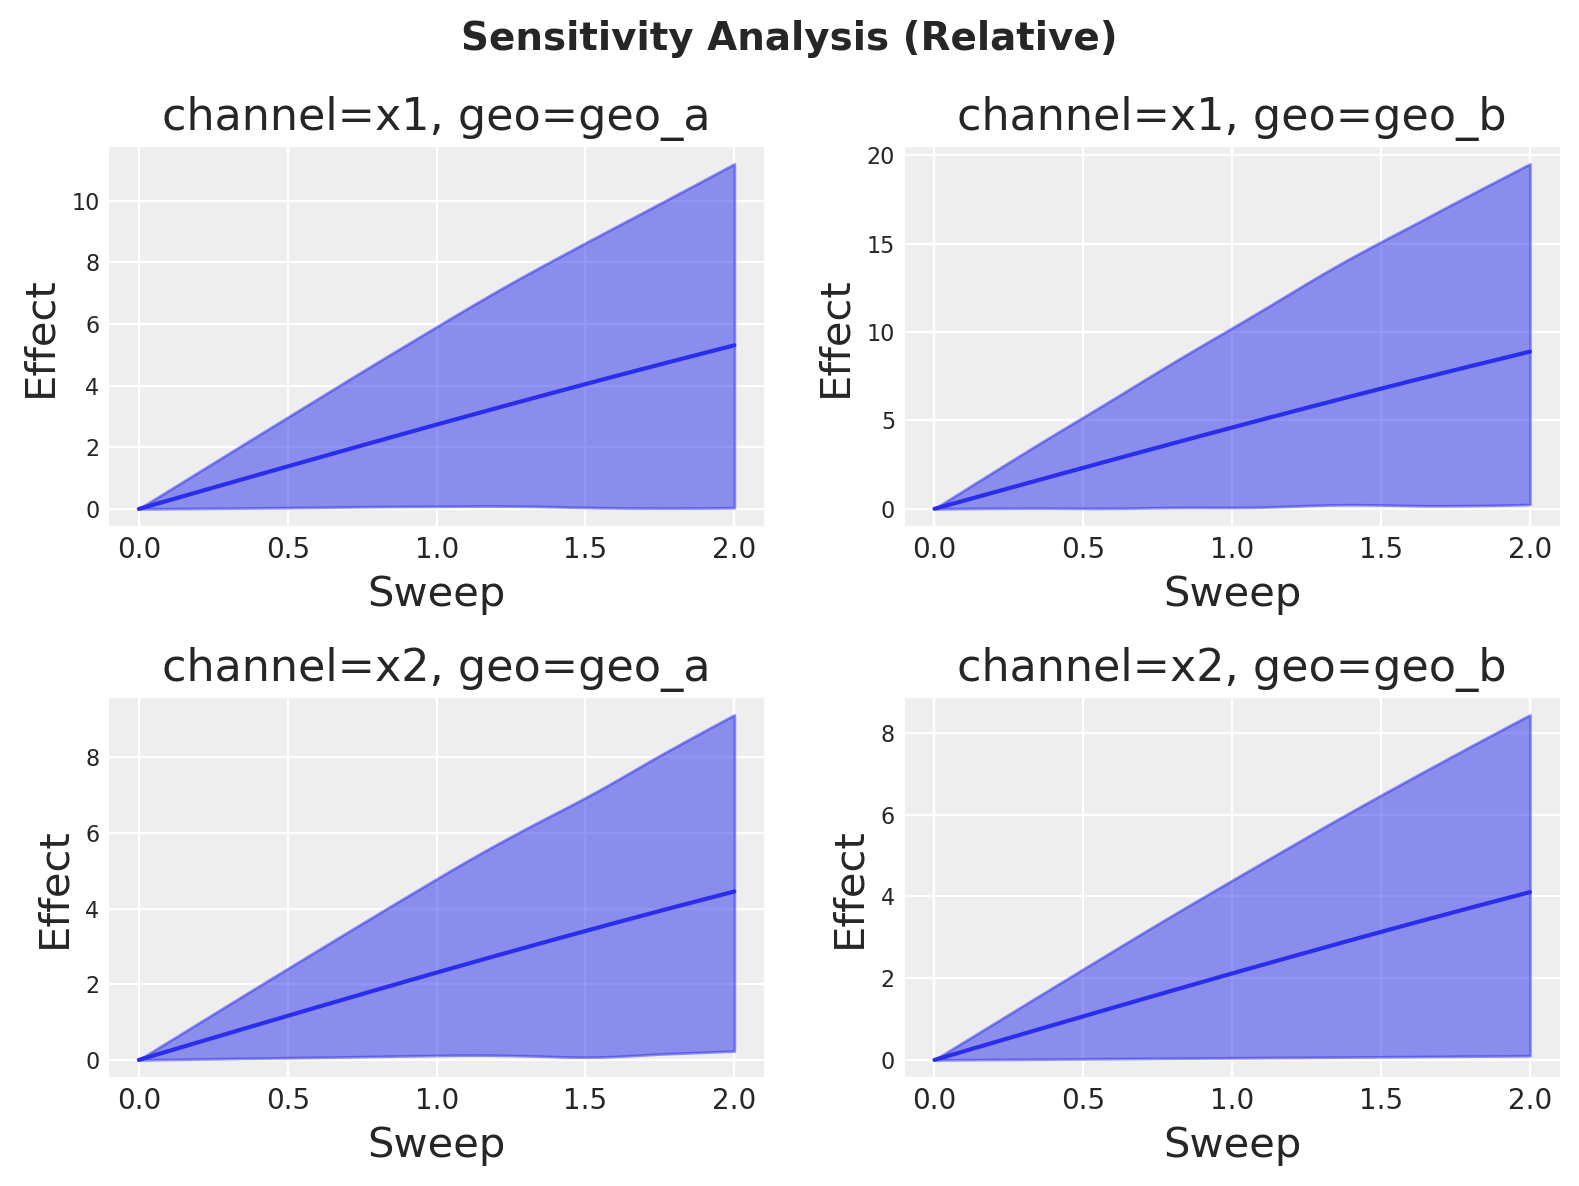

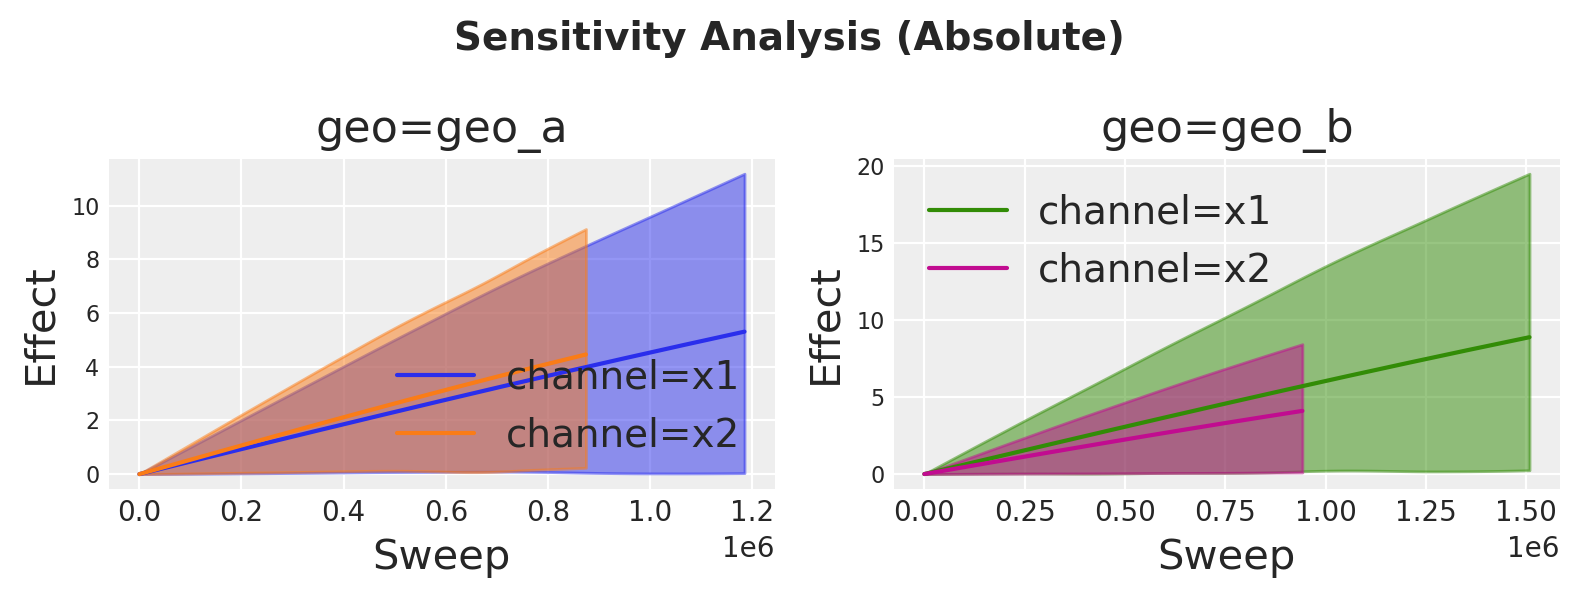

In [6]:
sweep_values = np.linspace(0.0, 2.0, 11)

report = MMMReport(
    mmm,
    hdi_probs=(0.50, 0.94),
    point_estimate="mean",
    frequency="monthly",
    roas_methods=("elementwise",),
    dims=None,
    sensitivity_sweep_values=tuple(sweep_values),
    include_interactive=False,
)

tables: dict[str, pd.DataFrame] = report.to_dataframe()
sorted(tables.keys())

In [7]:
for key in [
    "model_overview",
    "posterior_predictive",
    "total_contributions",
    "channel_contributions",
    "roas_elementwise",
    "saturation_curves",
    "sensitivity_analysis",
]:
    if key in tables:
        print(f"\n=== {key} ===")
        display(tables[key].head())


=== model_overview ===


,field,value
0,model_name,MMM
1,date_column,date
2,target_column,y
3,channels,"x1, x2"
4,controls,"event_1, event_2"



=== posterior_predictive ===


,date,geo,mean,median,abs_error_50_lower,abs_error_50_upper,abs_error_94_lower,abs_error_94_upper,observed,point_forecast
0,2022-06-06,geo_a,5034.728301,4982.082551,3120.472643,6537.401412,487.624255,9289.977889,2647.596355,5034.728301
1,2022-06-06,geo_b,3350.470713,3190.014653,1735.252830,4203.499948,75.977577,6392.657539,682.406280,3350.470713
2,2022-06-13,geo_a,5673.646246,5568.246558,3754.476305,7122.849650,1130.149370,10316.061491,5020.823907,5673.646246
3,2022-06-13,geo_b,3872.798320,3801.727217,2434.739422,5140.905927,264.098057,7187.783334,3753.104897,3872.798320
4,2022-06-20,geo_a,6317.392810,6294.310008,4713.495585,8050.448201,1711.141212,10958.424542,6184.322132,6317.392810



=== total_contributions ===


...

,index,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,"roas[x1, geo_a]",0.064,0.041,0.002,0.138,0.001,0.001,3611.0,2934.0,1.0
1,"roas[x1, geo_b]",0.067,0.045,0.001,0.149,0.001,0.001,2054.0,1822.0,1.0
2,"roas[x2, geo_a]",0.073,0.044,0.004,0.151,0.001,0.001,3611.0,3450.0,1.0
3,"roas[x2, geo_b]",0.049,0.031,0.001,0.103,0.000,0.000,3650.0,3372.0,1.0



=== saturation_curves ===


,channel,geo,x,mean,median,abs_error_50_lower,abs_error_50_upper,abs_error_94_lower,abs_error_94_upper,point_forecast
0,x1,geo_a,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,x1,geo_a,0.010101,6.050595,5.333638,3.086983,8.389797,0.741559,14.589360,6.050595
2,x1,geo_a,0.020202,12.101087,10.667166,6.173919,16.779547,1.483116,29.178648,12.101087
3,x1,geo_a,0.030303,18.151373,16.000475,9.260762,25.169203,2.224671,43.767789,18.151373
4,x1,geo_a,0.040404,24.201348,21.333454,12.347465,33.558718,2.966221,58.356713,24.201348



=== sensitivity_analysis ===


,sample,sweep,channel,geo,value
0,0,0.0,x1,geo_a,0.000000
1,0,0.0,x1,geo_b,0.000000
2,0,0.0,x2,geo_a,0.000000
3,0,0.0,x2,geo_b,0.000000
4,0,0.2,x1,geo_a,0.344263


## 4) What the other export methods are for

In day-to-day stakeholder workflows:

- `to_dataframe()` is ideal for analyst-driven slicing and quick QA.
- `to_html()` is ideal for sharing a narrative, visual report in one file.
- `to_excel()` is ideal for finance/marketing stakeholders who prefer spreadsheet workflows.
- `to_pdf()` is ideal for static distribution when teams require a fixed-format artifact.

### `MMMReport` constructor options

- `hdi_probs`: uncertainty intervals included in tables and used by report visuals.
- `point_estimate`: default point estimate used for `point_forecast` (`"mean"` or `"median"`).
- `frequency`: aggregation level for summaries (for example, `"all_time"`, `"monthly"`, `"weekly"`).
- `roas_methods`: include `"elementwise"`, `"incremental"`, or both.
- `dims`: optional filters for multidimensional outputs.
- `sensitivity_sweep_values`: optional values to run sensitivity analysis section.
- `include_interactive`: include interactive figures where available.
- `num_samples`: optional posterior subsampling for expensive computations.
- `random_state`: reproducibility for sampled computations.

### Export method options

- `to_html(file_name: str | None = None, save_intermediate_notebook: str | None = None)`
- `to_excel(file_name: str)`
- `to_pdf(file_name: str, engine: Literal["auto", "webpdf", "latex"] = "auto")`

## 5) Example export snippets (not executed)

```python
# Shareable report for broad stakeholder audience
report.to_html(file_name="mmm_report.html")
```

```python
# Spreadsheet handoff for planning and finance reviews
report.to_excel(file_name="mmm_report.xlsx")
```

```python
# Static report artifact (requires webpdf/latex tooling)
report.to_pdf(file_name="mmm_report.pdf", engine="auto")
```

These are intentionally shown as snippets to keep this notebook focused on the fastest path to insight (`to_dataframe()`).

'<!DOCTYPE html>\n\n<html lang="en">\n<head><meta charset="utf-8"/>\n<meta content="width=device-width, initial-scale=1.0" name="viewport"/>\n<title>Notebook</title><script src="https://cdnjs.cloudflare.com/ajax/libs/require.js/2.1.10/require.min.js"></script>\n<style type="text/css">\n    pre { line-height: 125%; }\ntd.linenos .normal { color: inherit; background-color: transparent; padding-left: 5px; padding-right: 5px; }\nspan.linenos { color: inherit; background-color: transparent; padding-left: 5px; padding-right: 5px; }\ntd.linenos .special { color: #000000; background-color: #ffffc0; padding-left: 5px; padding-right: 5px; }\nspan.linenos.special { color: #000000; background-color: #ffffc0; padding-left: 5px; padding-right: 5px; }\n.highlight .hll { background-color: var(--jp-cell-editor-active-background) }\n.highlight { background: var(--jp-cell-editor-background); color: var(--jp-mirror-editor-variable-color) }\n.highlight .c { color: var(--jp-mirror-editor-comment-color); fon
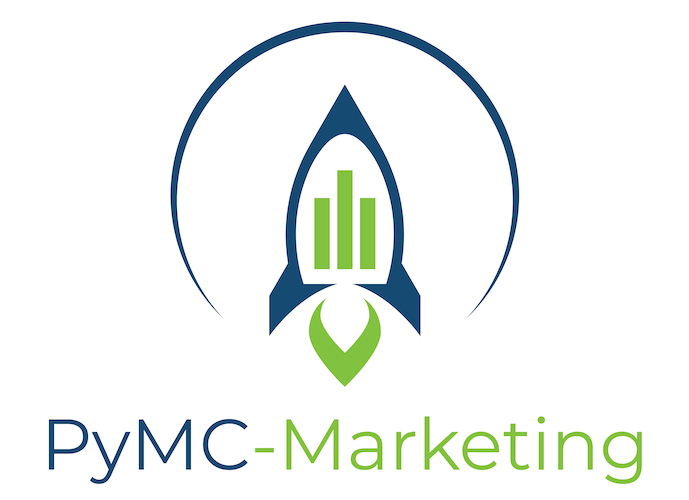
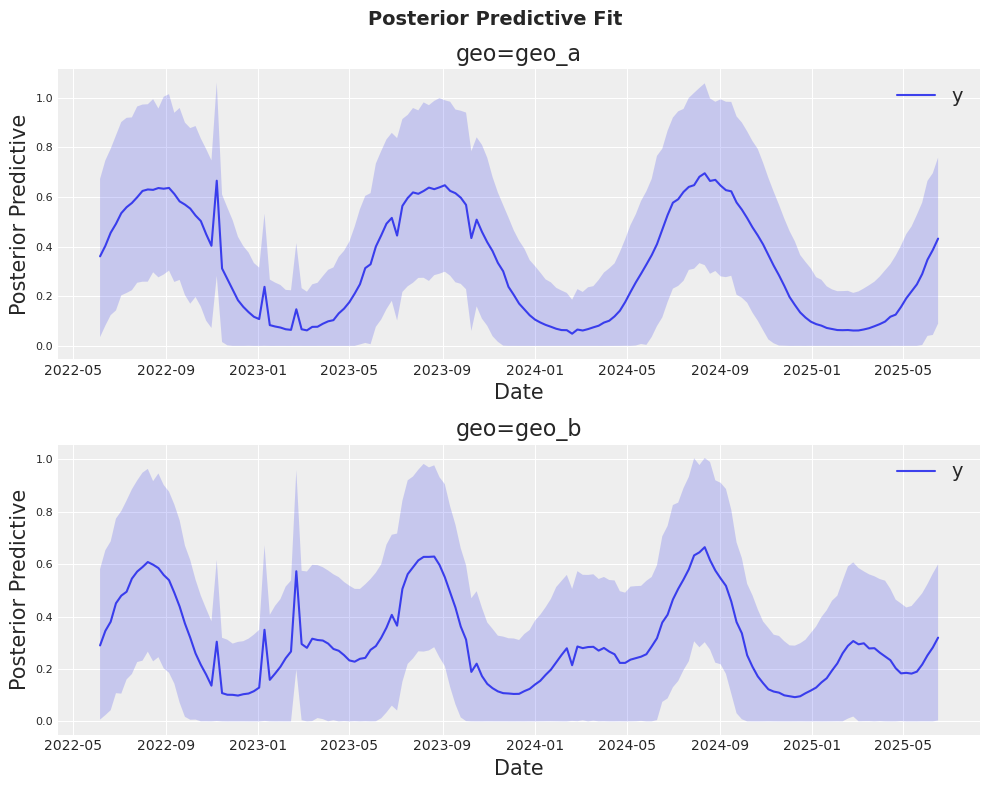
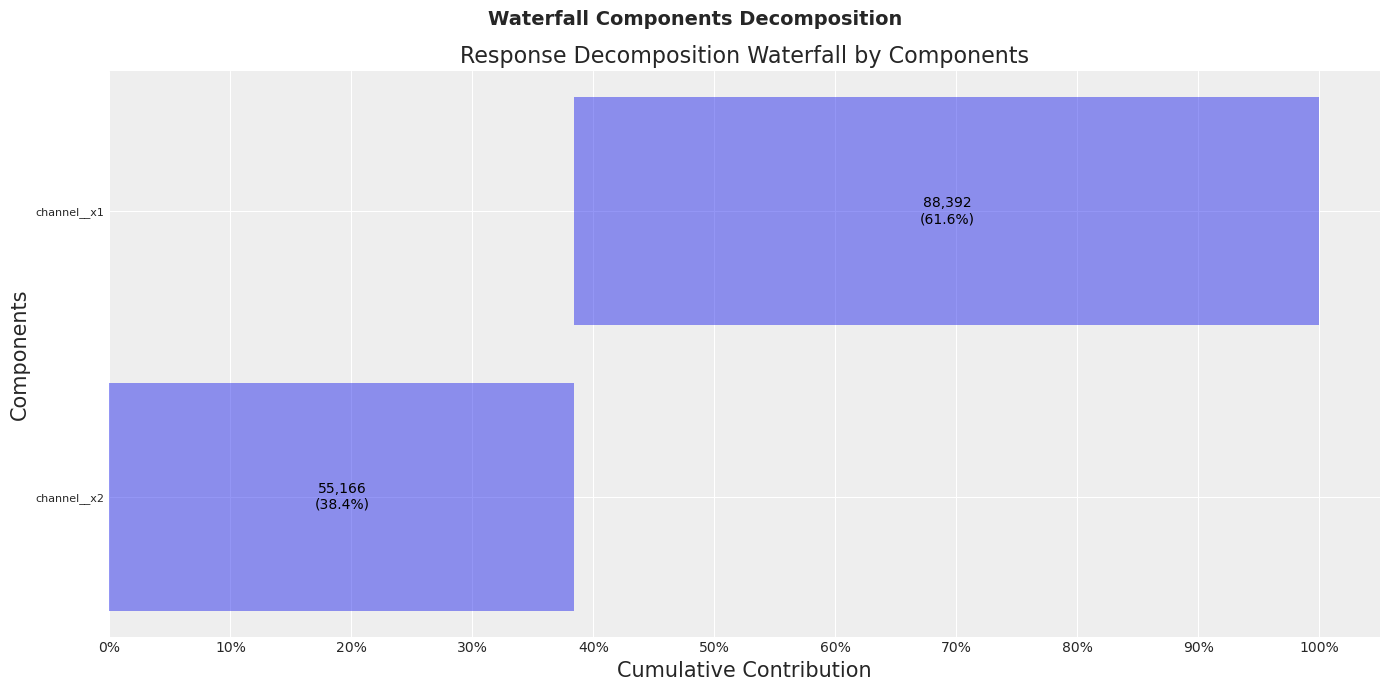
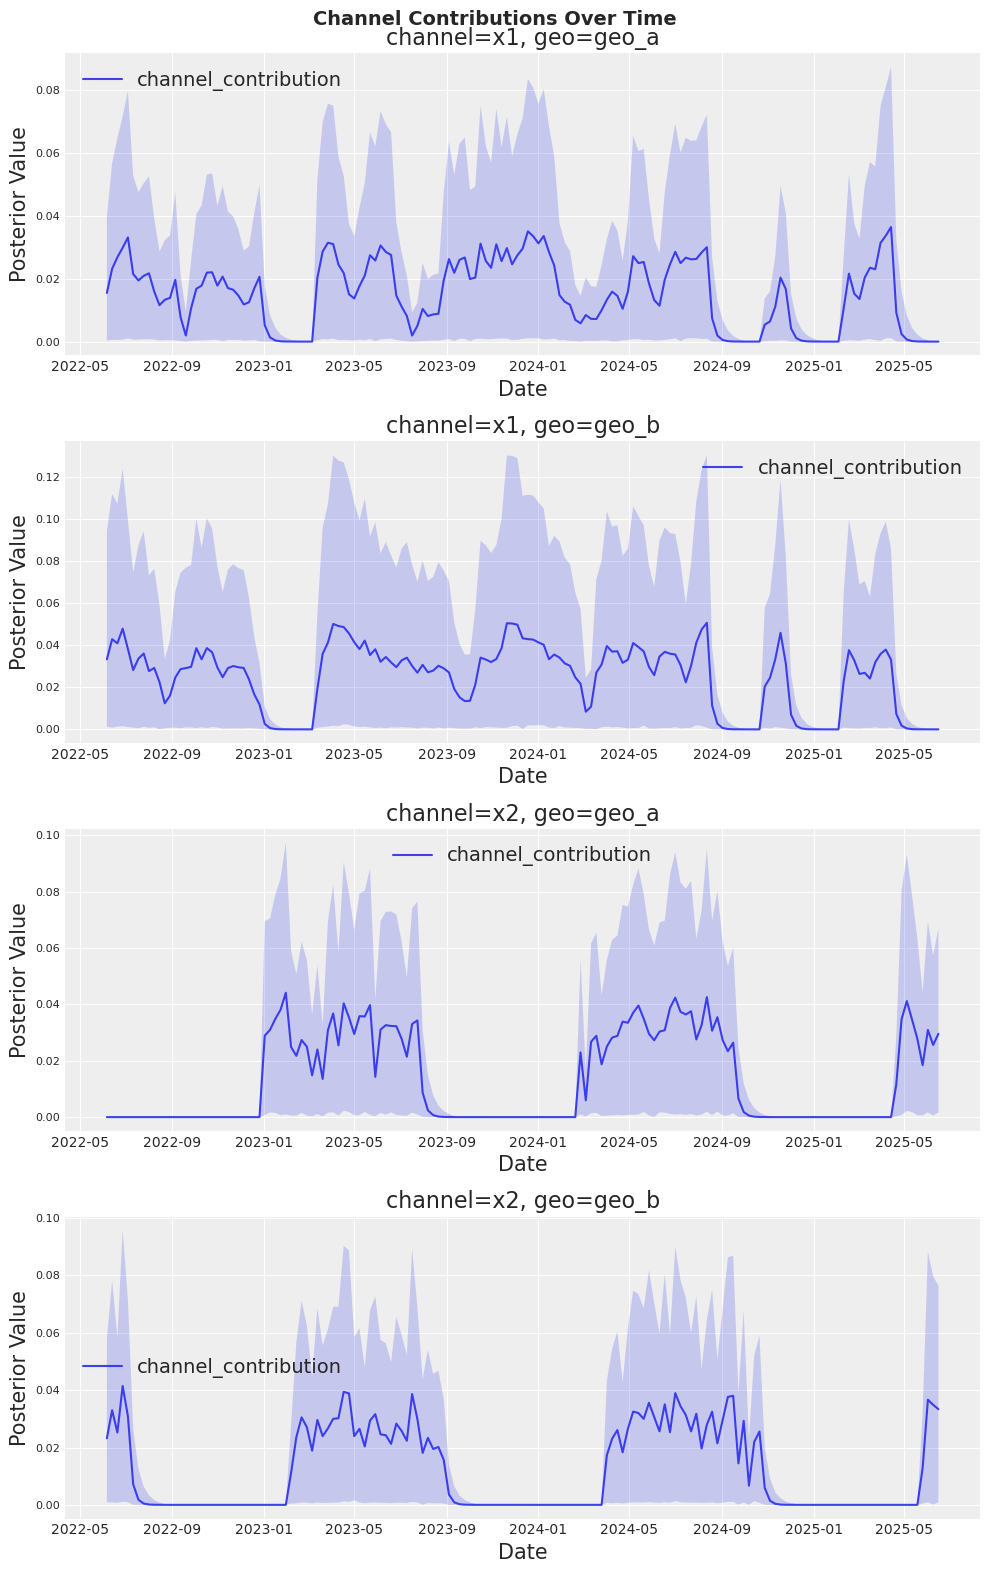
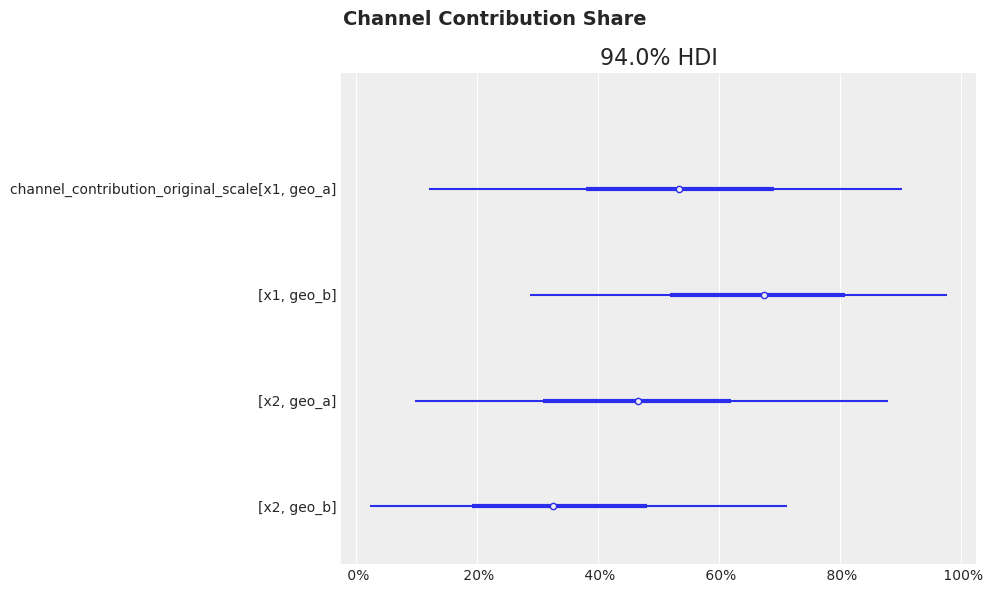
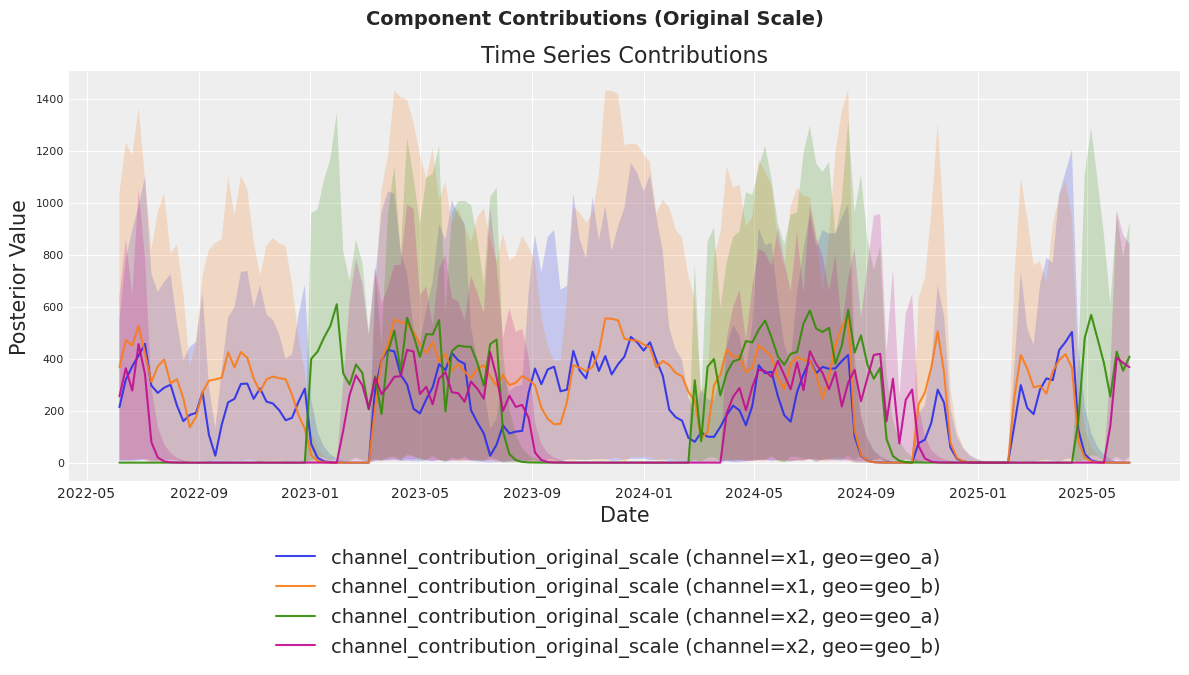
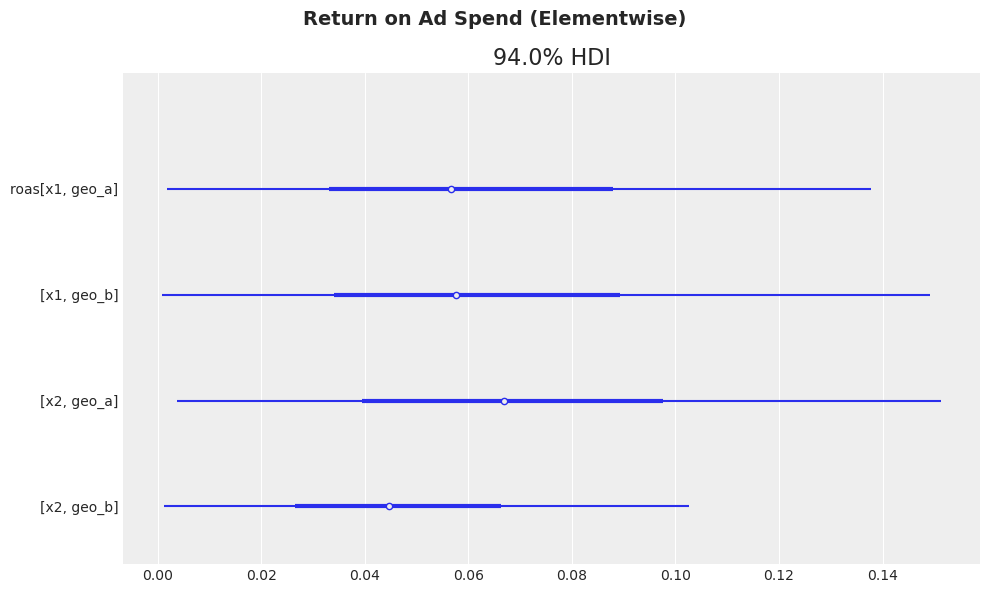
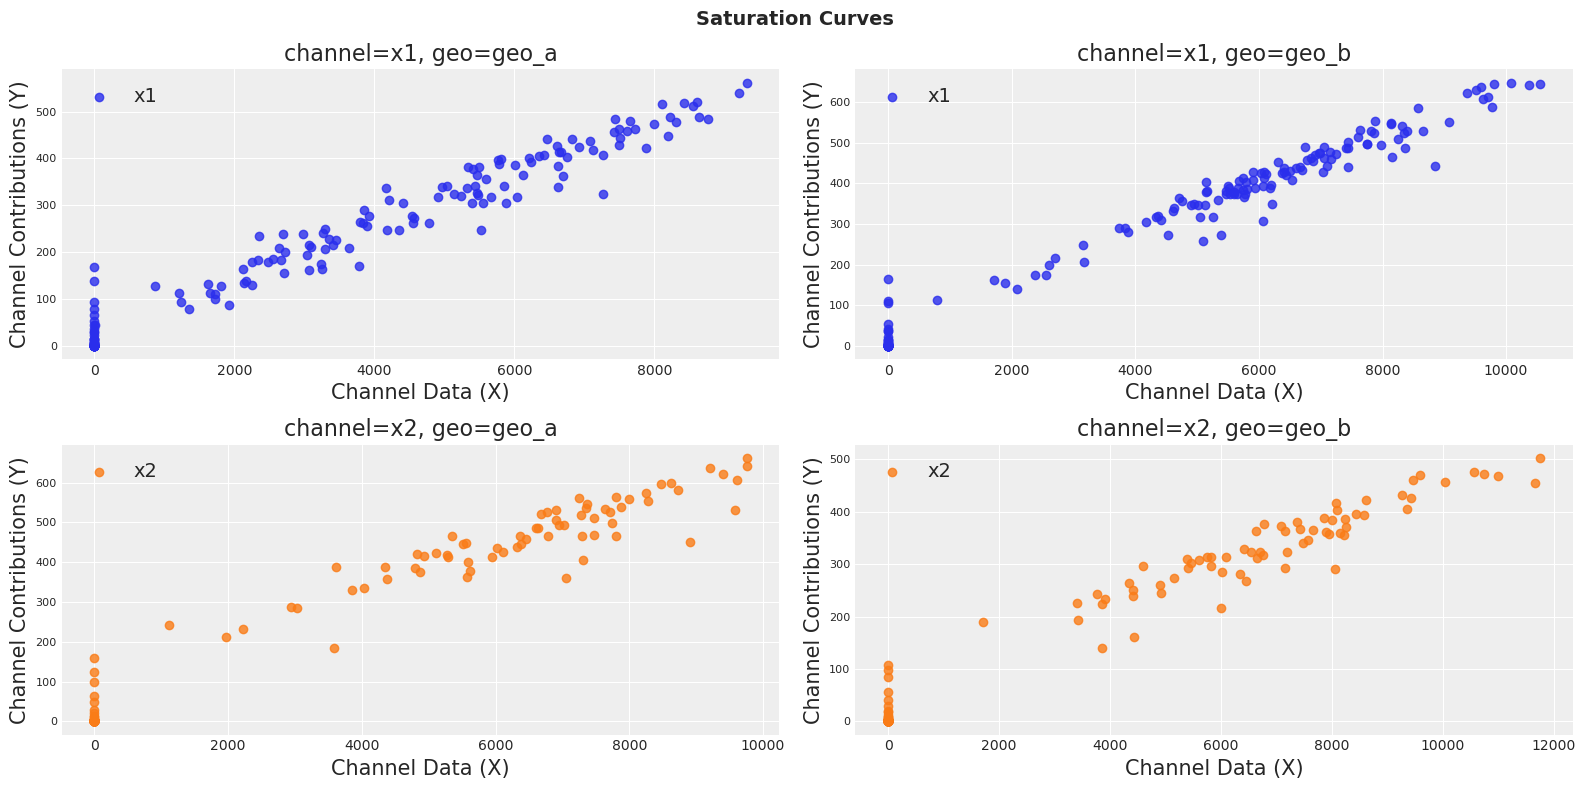
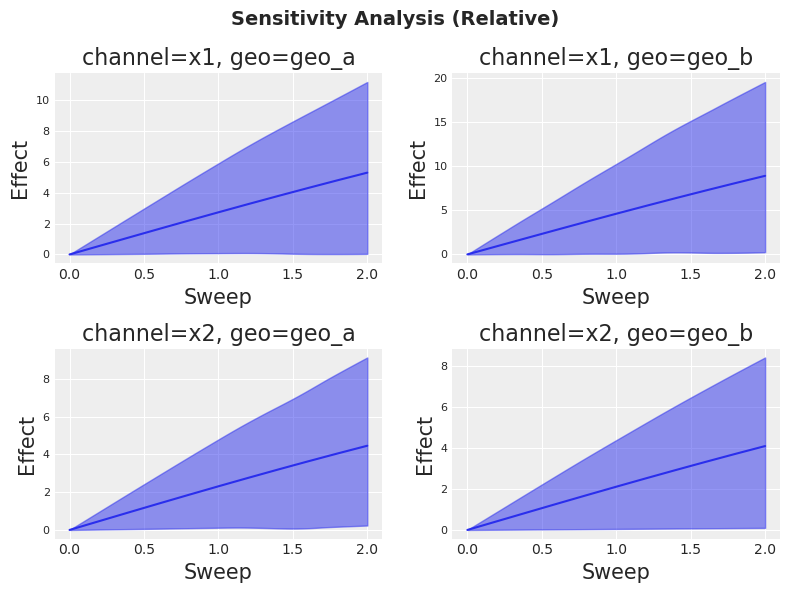
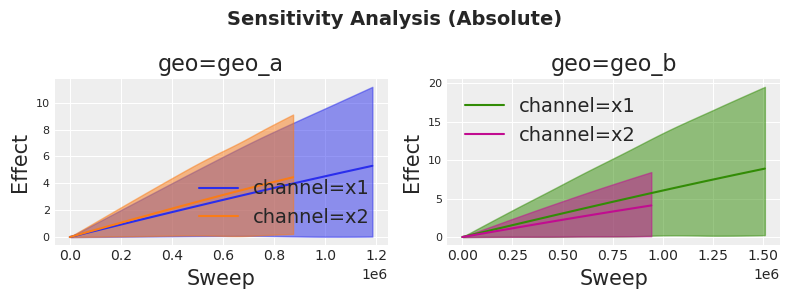

In [8]:
report.to_html(file_name="mmm_report.html")

In [9]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Mon, 23 Mar 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.11.0

IPython       : 9.11.0
arviz         : 0.23.4
matplotlib    : 3.10.8
numpy         : 2.4.2
pandas        : 2.3.3
pymc_extras   : 0.9.3
pymc_marketing: 0.18.2

Watermark: 2.6.0



In [10]:
report.to_excel("report.xlsx")